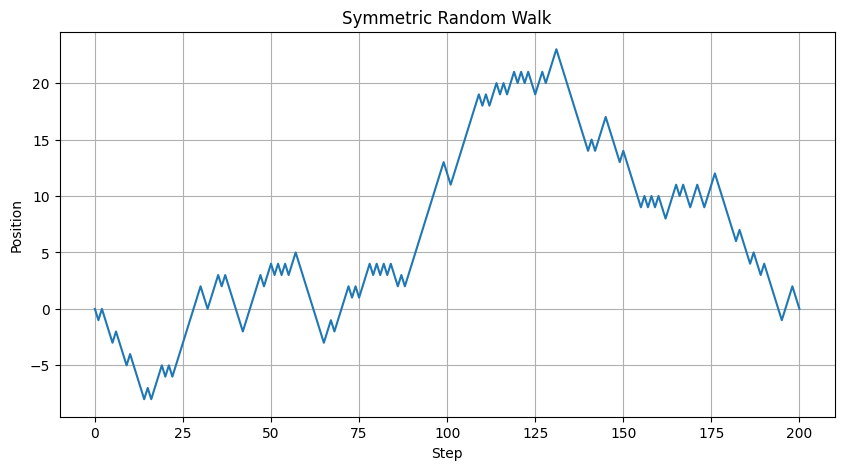

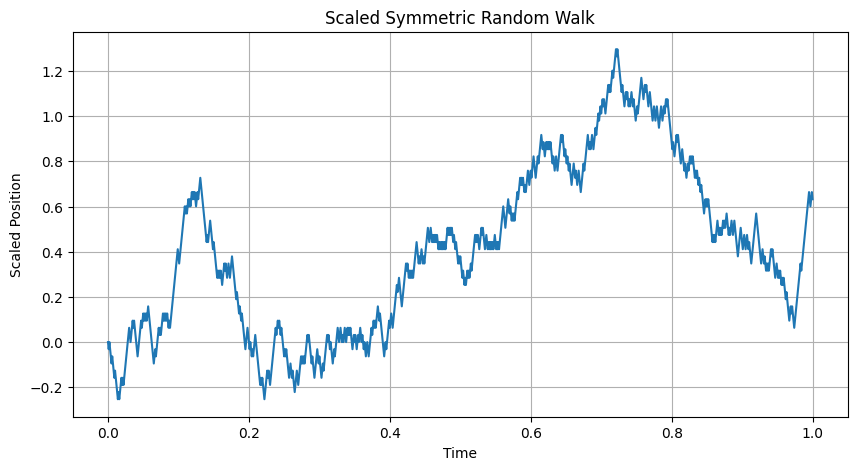

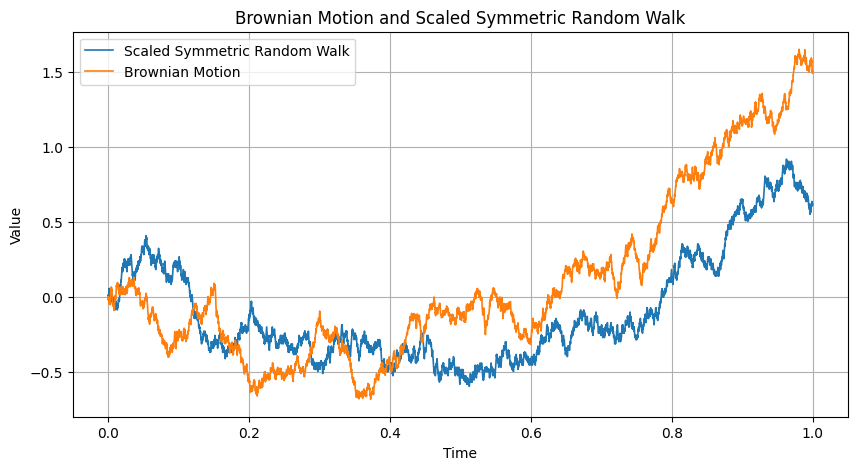

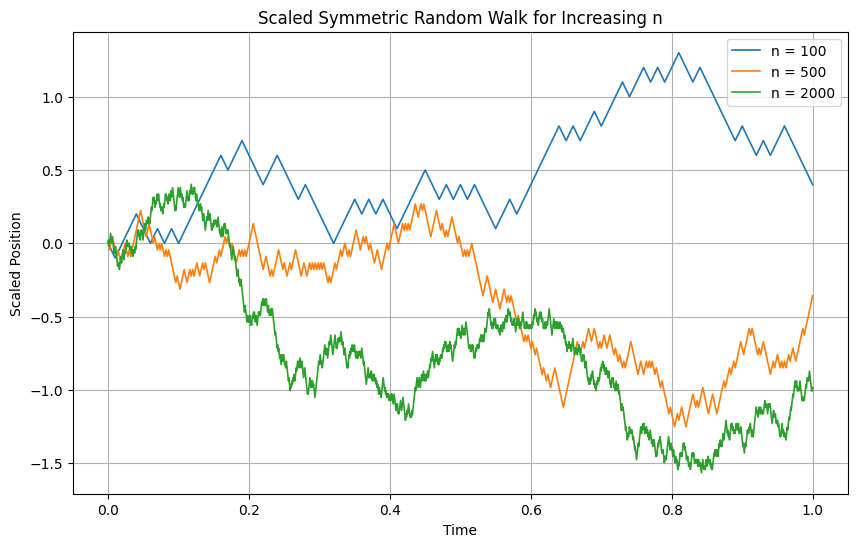

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Symmetric Random Walk
# -----------------------------
def simulate_symmetric_random_walk(n_steps, seed=None):
    """
    Simulate a simple symmetric random walk:
    S_0 = 0, S_n = X_1 + ... + X_n
    where each X_i is +1 or -1 with probability 1/2.
    """
    if seed is not None:
        np.random.seed(seed)

    increments = np.random.choice([-1, 1], size=n_steps)
    positions = np.concatenate(([0], np.cumsum(increments)))
    return positions, increments


# -----------------------------
# 2. Scaled Symmetric Random Walk
# -----------------------------
def simulate_scaled_symmetric_random_walk(n_steps, T=1.0, seed=None):
    """
    Simulate the scaled symmetric random walk on [0, T]:

    W_n(t_k) = sqrt(T/n) * S_k,   where t_k = kT/n

    This is the usual scaling used to approximate Brownian motion.
    """
    positions, increments = simulate_symmetric_random_walk(n_steps, seed=seed)
    dt = T / n_steps
    times = np.linspace(0, T, n_steps + 1)
    scaled_positions = np.sqrt(dt) * positions
    return times, scaled_positions, increments


# -----------------------------
# 3. Brownian Motion
# -----------------------------
def simulate_brownian_motion(n_steps, T=1.0, seed=None):
    """
    Simulate Brownian motion on [0, T]:

    B_0 = 0,
    B_{t_{k+1}} - B_{t_k} ~ N(0, dt)
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    increments = np.sqrt(dt) * np.random.randn(n_steps)
    path = np.concatenate(([0], np.cumsum(increments)))
    times = np.linspace(0, T, n_steps + 1)
    return times, path, increments


# -----------------------------
# Plot 1: Symmetric Random Walk
# -----------------------------
n_steps_rw = 200
rw_positions, rw_increments = simulate_symmetric_random_walk(n_steps_rw, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(range(n_steps_rw + 1), rw_positions, linewidth=1.5)
plt.xlabel("Step")
plt.ylabel("Position")
plt.title("Symmetric Random Walk")
plt.grid(True)
plt.show()


# -----------------------------
# Plot 2: Scaled Symmetric Random Walk
# -----------------------------
n_steps_scaled = 1000
T = 1.0
times_scaled, scaled_path, _ = simulate_scaled_symmetric_random_walk(n_steps_scaled, T=T, seed=42)

plt.figure(figsize=(10, 5))
plt.plot(times_scaled, scaled_path, linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Scaled Position")
plt.title("Scaled Symmetric Random Walk")
plt.grid(True)
plt.show()


# -----------------------------
# Plot 3: Brownian Motion vs Scaled Random Walk
# -----------------------------
n_steps_bm = 5000
times_bm, brownian_path, _ = simulate_brownian_motion(n_steps_bm, T=T, seed=123)
times_scaled_large, scaled_path_large, _ = simulate_scaled_symmetric_random_walk(n_steps_bm, T=T, seed=7)

plt.figure(figsize=(10, 5))
plt.plot(times_scaled_large, scaled_path_large, label="Scaled Symmetric Random Walk", linewidth=1.2)
plt.plot(times_bm, brownian_path, label="Brownian Motion", linewidth=1.2)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Brownian Motion and Scaled Symmetric Random Walk")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Plot 4: Increasing n to show convergence idea
# -----------------------------
n_values = [100, 500, 2000]

plt.figure(figsize=(10, 6))
for n in n_values:
    t, path, _ = simulate_scaled_symmetric_random_walk(n, T=1.0)
    plt.plot(t, path, label=f"n = {n}", linewidth=1.2)

plt.xlabel("Time")
plt.ylabel("Scaled Position")
plt.title("Scaled Symmetric Random Walk for Increasing n")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
def simulate_symmetric_random_walk(n_steps, seed=None):
    if seed is not None:
        np.random.seed(seed)
    increments = np.random.choice([-1, 1], size=n_steps)
    positions = np.concatenate(([0], np.cumsum(increments)))
    times = np.arange(n_steps + 1)
    return times, positions


def simulate_scaled_symmetric_random_walk(n_steps, T=1.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    increments = np.random.choice([-1, 1], size=n_steps)
    positions = np.concatenate(([0], np.cumsum(increments)))
    dt = T / n_steps
    scaled_positions = np.sqrt(dt) * positions
    times = np.linspace(0, T, n_steps + 1)
    return times, scaled_positions


def simulate_brownian_motion(n_steps, T=1.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    dt = T / n_steps
    increments = np.sqrt(dt) * np.random.randn(n_steps)
    path = np.concatenate(([0], np.cumsum(increments)))
    times = np.linspace(0, T, n_steps + 1)
    return times, path

In [26]:
n_steps = 200
times_rw, positions_rw = simulate_symmetric_random_walk(n_steps, seed=42)

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot([], [], lw=2)

ax.set_xlim(0, n_steps)
ax.set_ylim(positions_rw.min() - 5, positions_rw.max() + 5)
ax.set_xlabel("Step")
ax.set_ylabel("Position")
ax.set_title("Animated Symmetric Random Walk")
ax.grid(True)

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(times_rw[:frame+1], positions_rw[:frame+1])
    return line,

anim_rw = FuncAnimation(fig, update, frames=len(times_rw), init_func=init,
                        interval=40, blit=True)

plt.close(fig)
HTML(anim_rw.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
n_steps = 1000
T = 1.0
times_scaled, positions_scaled = simulate_scaled_symmetric_random_walk(n_steps, T=T, seed=42)

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot([], [], lw=2)

ax.set_xlim(0, T)
ax.set_ylim(positions_scaled.min() - 0.5, positions_scaled.max() + 0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Scaled Position")
ax.set_title("Animated Scaled Symmetric Random Walk")
ax.grid(True)

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(times_scaled[:frame+1], positions_scaled[:frame+1])
    return line,

anim_scaled = FuncAnimation(fig, update, frames=len(times_scaled), init_func=init,
                            interval=10, blit=True)

plt.close(fig)
HTML(anim_scaled.to_jshtml())

In [ ]:
n_steps = 1500
T = 1.0

times_scaled, positions_scaled = simulate_scaled_symmetric_random_walk(n_steps, T=T, seed=7)
times_bm, positions_bm = simulate_brownian_motion(n_steps, T=T, seed=123)

y_min = min(positions_scaled.min(), positions_bm.min()) - 0.5
y_max = max(positions_scaled.max(), positions_bm.max()) + 0.5

fig, ax = plt.subplots(figsize=(10, 5))
line_scaled, = ax.plot([], [], lw=2, label="Scaled Symmetric Random Walk")
line_bm, = ax.plot([], [], lw=2, label="Brownian Motion")

ax.set_xlim(0, T)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Brownian Motion as the Limit of Scaled Symmetric Random Walk")
ax.legend()
ax.grid(True)

def init():
    line_scaled.set_data([], [])
    line_bm.set_data([], [])
    return line_scaled, line_bm

def update(frame):
    line_scaled.set_data(times_scaled[:frame+1], positions_scaled[:frame+1])
    line_bm.set_data(times_bm[:frame+1], positions_bm[:frame+1])
    return line_scaled, line_bm

anim_compare = FuncAnimation(fig, update, frames=len(times_scaled), init_func=init,
                             interval=10, blit=True)

plt.close(fig)
HTML(anim_compare.to_jshtml())

In [ ]:
n_values = [50, 100, 200, 500, 1000, 2000]
T = 1.0

paths = []
for i, n in enumerate(n_values):
    t, x = simulate_scaled_symmetric_random_walk(n, T=T, seed=100 + i)
    paths.append((n, t, x))

all_y = np.concatenate([p[2] for p in paths])

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot([], [], lw=2)
title = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center", fontsize=12)

ax.set_xlim(0, T)
ax.set_ylim(all_y.min() - 0.5, all_y.max() + 0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Scaled Position")
ax.grid(True)

def init():
    line.set_data([], [])
    title.set_text("")
    return line, title

def update(frame):
    n, t, x = paths[frame]
    line.set_data(t, x)
    title.set_text(f"Scaled Symmetric Random Walk with n = {n}")
    return line, title

anim_limit = FuncAnimation(fig, update, frames=len(paths), init_func=init,
                           interval=1000, blit=True)

plt.close(fig)
HTML(anim_limit.to_jshtml())